In [3]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, ClassifierMixin

# utility to load pickled files
def unpickle(file):
    with open(file, 'rb') as f:
        return pickle.load(f)

# load features and labels extracted from ResNet
def load_data():
    data_dir = "PRMLProject/PreProcessedData/"

    if not os.path.exists(data_dir):
        os.system("git clone https://github.com/varaiitj2527/PRMLProject.git")

    X_train = unpickle(os.path.join(data_dir, "TrainFeaturesHoG.pkl"))
    y_train = unpickle(os.path.join(data_dir, "Labels_train.pkl"))
    X_test = unpickle(os.path.join(data_dir, "TestFeaturesHoG.pkl"))
    y_test = unpickle(os.path.join(data_dir, "Labels_test.pkl"))

    X_train = np.array(X_train).reshape(len(X_train), -1)
    X_test = np.array(X_test).reshape(len(X_test), -1)

    print("Train shape:", X_train.shape)
    print("Test shape:", X_test.shape)

    return X_train, y_train, X_test, y_test

# load everything
X_train, y_train, X_test, y_test = load_data()


Train shape: (50000, 324)
Test shape: (10000, 324)


In [4]:
# custom SVM from scratch using SGD
class CustomSVM(BaseEstimator, ClassifierMixin):
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000, kernel='linear', C=1.0, gamma=0.01):
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.kernel = kernel
        self.C = C
        self.gamma = gamma
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y_ = np.where(y <= 0, -1, 1)
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in tqdm(range(self.n_iters), desc="Training SVM"):
            loss = 0
            for idx in range(n_samples):
                x_i, y_i = X[idx], y_[idx]
                condition = y_i * (np.dot(x_i, self.w) - self.b) >= 1

                if condition:
                    self.w -= self.learning_rate * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.learning_rate * (2 * self.lambda_param * self.w - np.dot(x_i, y_i))
                    self.b -= self.learning_rate * y_i
                    loss += 1 - y_i * (np.dot(x_i, self.w) - self.b)

            self.loss_history.append(loss)

        return self

    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.where(approx >= 0, 1, 0)

    def get_params(self, deep=True):
        return {
            "learning_rate": self.learning_rate,
            "lambda_param": self.lambda_param,
            "n_iters": self.n_iters,
            "kernel": self.kernel,
            "C": self.C,
            "gamma": self.gamma
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

# simple grid search on custom SVM
def tune_parameters(X_train, y_train):
    model = CustomSVM(kernel='linear', n_iters=500)

    param_grid = {
        'C': [0.01, 0.1, 1, 10],
        'learning_rate': [0.0001, 0.001, 0.01]
    }

    search = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', verbose=2, return_train_score=True)
    search.fit(X_train, y_train)

    print("Best parameters found:", search.best_params_)
    return search.best_params_, search


In [5]:
# run grid search to find the best combination of C and learning rate
best_params, grid_search = tune_parameters(X_train, y_train)


Fitting 3 folds for each of 12 candidates, totalling 36 fits


Training SVM: 100%|██████████| 500/500 [02:27<00:00,  3.40it/s]


[CV] END .......................C=0.01, learning_rate=0.0001; total time= 2.5min


Training SVM: 100%|██████████| 500/500 [02:07<00:00,  3.93it/s]


[CV] END .......................C=0.01, learning_rate=0.0001; total time= 2.1min


...

[CV] END ...........................C=10, learning_rate=0.01; total time= 2.1min


Training SVM: 100%|██████████| 500/500 [02:03<00:00,  4.05it/s]


[CV] END ...........................C=10, learning_rate=0.01; total time= 2.1min


Training SVM: 100%|██████████| 500/500 [03:07<00:00,  2.66it/s]

Best parameters found: {'C': 0.01, 'learning_rate': 0.0001}


In [6]:
print("✅ Tuning complete. Best hyperparameters:")
print(best_params)


✅ Tuning complete. Best hyperparameters:
{'C': 0.01, 'learning_rate': 0.0001}


In [7]:
# using the best found hyperparameters to train the final model
svm = CustomSVM(**best_params, kernel='linear', n_iters=1000)
svm.fit(X_train, y_train)

# make predictions on the test set
y_pred = svm.predict(X_test)


Training SVM: 100%|██████████| 1000/1000 [06:17<00:00,  2.65it/s]


In [8]:
# evaluate how well the model did on the test set
acc = accuracy_score(y_test, y_pred)
print(f"🎯 Test Accuracy: {acc:.4f}")


🎯 Test Accuracy: 0.1000


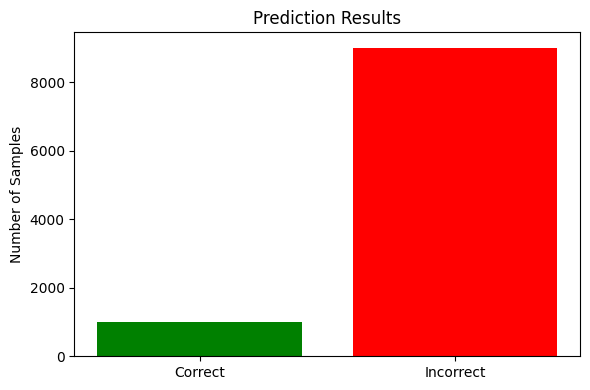

In [9]:
# simple bar plot to show correct vs incorrect predictions
correct = np.sum(y_pred == y_test)
incorrect = np.sum(y_pred != y_test)

plt.figure(figsize=(6, 4))
plt.bar(['Correct', 'Incorrect'], [correct, incorrect], color=['green', 'red'])
plt.title("Prediction Results")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()


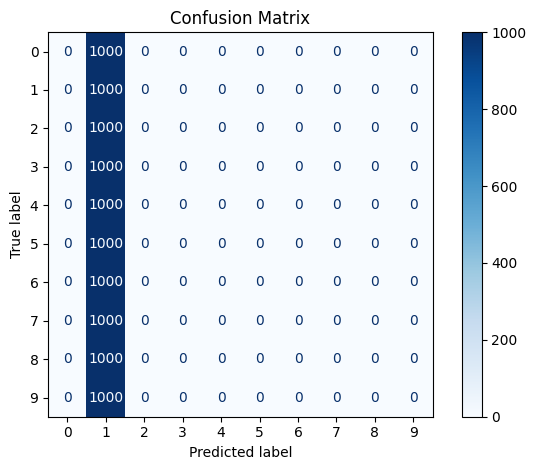

In [10]:
# 1. Confusion Matrix to visualize model's classification performance
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [11]:
# print a detailed classification report showing precision, recalla, f1-score
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))



📊 Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.10      1.00      0.18      1000
           2       0.00      0.00      0.00      1000
           3       0.00      0.00      0.00      1000
           4       0.00      0.00      0.00      1000
           5       0.00      0.00      0.00      1000
           6       0.00      0.00      0.00      1000
           7       0.00      0.00      0.00      1000
           8       0.00      0.00      0.00      1000
           9       0.00      0.00      0.00      1000

    accuracy                           0.10     10000
   macro avg       0.01      0.10      0.02     10000
weighted avg       0.01      0.10      0.02     10000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


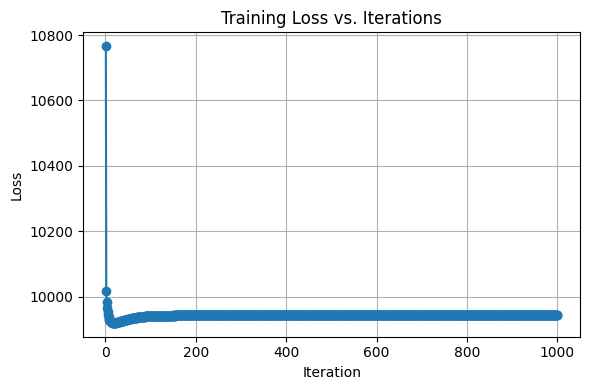

In [12]:
# plot the loss curve to visualize model convergence during training
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(svm.loss_history) + 1), svm.loss_history, marker='o')
plt.title("Training Loss vs. Iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


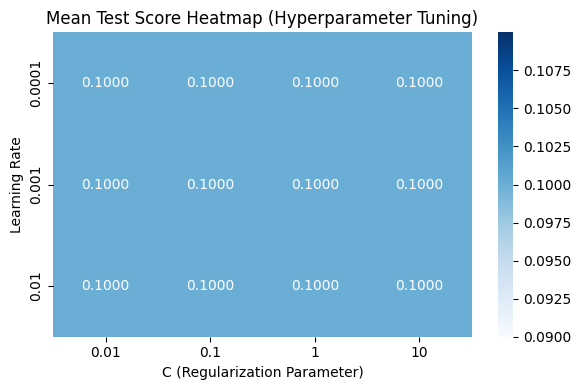

In [14]:
# 4. Heatmap to visualize the mean test scores from grid search results
import seaborn as sns
scores = grid_search.cv_results_['mean_test_score']
learning_rates = [0.0001, 0.001, 0.01]
Cs = [0.01, 0.1, 1, 10]

# reshape the scores to match the grid of hyperparameters
scores_matrix = scores.reshape(len(learning_rates), len(Cs))

# plot the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(scores_matrix, annot=True, fmt=".4f", xticklabels=Cs, yticklabels=learning_rates, cmap="Blues")
plt.title("Mean Test Score Heatmap (Hyperparameter Tuning)")
plt.xlabel("C (Regularization Parameter)")
plt.ylabel("Learning Rate")
plt.tight_layout()
plt.show()


In [ ]:
# Alternative visualization: Heatmap for grid search results using imshow
plt.figure(figsize=(8, 6))
plt.imshow(scores_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar()  # Add color bar to indicate score range
plt.title("Grid Search Mean Test Accuracy")
plt.xlabel("C Values (Regularization)")
plt.ylabel("Learning Rate")
plt.xticks(np.arange(len(Cs)), Cs)
plt.yticks(np.arange(len(learning_rates)), learning_rates)
plt.tight_layout()
plt.show()
